In [1]:
import os
import cv2
import numpy as np
from pathlib import Path
import urllib.request
import tarfile
from tqdm import tqdm

In [2]:
# Clone the BSDS500 GitHub repo
!git clone https://github.com/BIDS/BSDS500.git

Cloning into 'BSDS500'...
remote: Enumerating objects: 2380, done.
remote: Total 2380 (delta 0), reused 0 (delta 0), pack-reused 2380 (from 1)
Receiving objects: 100% (2380/2380), 155.21 MiB | 22.45 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (2268/2268), done.


In [3]:
# Base image folder
base_path = Path("BSDS500/BSDS500/data/images")
# Collect all training images
img_paths = list((base_path / "train").glob("*.*")) \
            + list((base_path / "val").glob("*.*"))

img_paths_test = list((base_path / "test").glob("*.*"))

print(f"Found {len(img_paths)} images for training.")
print(f"Found {len(img_paths_test)} images for testing.")

Found 302 images for training.
Found 201 images for testing.


In [14]:
# -----------------------------
# 2. Patch settings
# -----------------------------
patch_size = 50
stride = 25  # overlap
sigma_min, sigma_max = 0.01, 0.2  # Gaussian noise range for normalized images

# Limit patches
max_train_patches = 10000   # e.g., max 5000 patches for training
max_test_patches = 5000

def extract_patches(img, patch_size=50, stride=25):
    patches = []
    h, w = img.shape[:2]
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    return patches

def add_gaussian_noise(patch):
    # normalizing patch
    patch = patch.astype(np.float32) / 255.0

    sigma = np.random.uniform(sigma_min, sigma_max)
    noise = np.random.normal(0, sigma, patch.shape).astype(np.float32)
    noisy = np.clip(patch + noise, 0, 1)
    residual = noisy - patch
    return noisy, residual

# -----------------------------
# 3. Generate train data
# -----------------------------
train_noisy = []
train_residual = []

for img_path in tqdm(img_paths):
    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img is None:
        continue
    patches = extract_patches(img, patch_size, stride)
    for patch in patches:
        if len(train_noisy) >= max_train_patches:
            break
        noisy, residual = add_gaussian_noise(patch)
        train_noisy.append(noisy)
        train_residual.append(residual)

train_noisy = np.array(train_noisy, dtype=np.float32)
train_residual = np.array(train_residual, dtype=np.float32)
print(f"Train patches: {train_noisy.shape[0]}")

# Save train data
np.savez_compressed("dncnn_train.npz", noisy=train_noisy, residual=train_residual)

# -----------------------------
# 4. Generate test data
# -----------------------------
test_noisy = []
test_residual = []

for img_path in tqdm(img_paths_test):
    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img is None:
        continue
    patches = extract_patches(img, patch_size, stride)
    for patch in patches:
        if len(test_noisy) >= max_test_patches:
            break
        noisy, residual = add_gaussian_noise(patch)
        test_noisy.append(noisy)
        test_residual.append(residual)

test_noisy = np.array(test_noisy, dtype=np.float32)
test_residual = np.array(test_residual, dtype=np.float32)
print(f"Test patches: {test_noisy.shape[0]}")

# Save test data
np.savez_compressed("dncnn_test.npz", noisy=test_noisy, residual=test_residual)

100%|██████████| 302/302 [00:03<00:00, 76.47it/s] 


Train patches: 10000


100%|██████████| 201/201 [00:01<00:00, 134.18it/s]


Test patches: 5000


2084


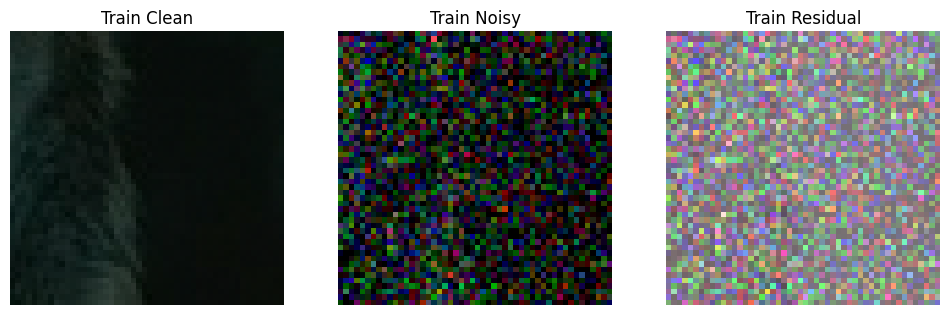

1891


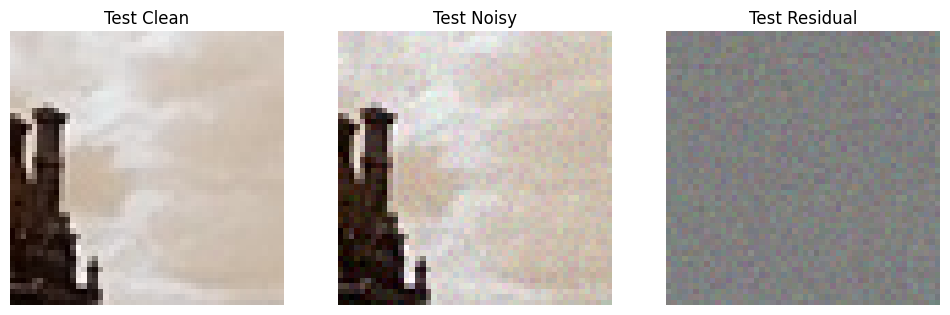

In [15]:
import matplotlib.pyplot as plt
def show_random_sample(noisy, residual, title):

    idx = np.random.randint(0, len(noisy)-1)
    print(idx)

    noisy_img = noisy[idx]
    residual_img = residual[idx]

    # Reconstruct clean image
    clean_img = noisy_img - residual_img

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(clean_img)
    plt.title(f"{title} Clean")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(noisy_img)
    plt.title(f"{title} Noisy")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(residual_img + 0.5)  # shift for visualization
    plt.title(f"{title} Residual")
    plt.axis("off")

    plt.show()


# Show random train sample
show_random_sample(train_noisy, train_residual, "Train")

# Show random test sample
show_random_sample(test_noisy, test_residual, "Test")

In [16]:
print("Train shape:", train_noisy.shape)
print("Test shape:", test_noisy.shape)

import torch
import torch.nn as nn

class SimpleDnCNN(nn.Module):

    def __init__(self):
        super(SimpleDnCNN, self).__init__()

        self.net = nn.Sequential(

            # Input: 3x50x50
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Output residual
            nn.Conv2d(64, 3, kernel_size=3, padding=1)

        )

    def forward(self, x):
        return self.net(x)

Train shape: (10000, 50, 50, 3)
Test shape: (5000, 50, 50, 3)


In [17]:
# -------------------------
# Weight init (Kaiming)
# -------------------------
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleDnCNN().to(device)

model.apply(init_weights)   # apply once before training

print(model)

SimpleDnCNN(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [18]:

# Load data
train = np.load("dncnn_train.npz")
test  = np.load("dncnn_test.npz")

# Data is in NHWC, torch expects NCHW
X_train = torch.tensor(train["noisy"]).permute(0,3,1,2).float()
Y_train = torch.tensor(train["residual"]).permute(0,3,1,2).float()

X_test = torch.tensor(test["noisy"]).permute(0,3,1,2).float()
Y_test = torch.tensor(test["residual"]).permute(0,3,1,2).float()

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

torch.Size([10000, 3, 50, 50])
torch.Size([10000, 3, 50, 50])
torch.Size([5000, 3, 50, 50])
torch.Size([5000, 3, 50, 50])


In [19]:
best_loss = float('inf')
epochs = 300
batch = 50

loss_fn = nn.MSELoss()
scaler = torch.cuda.amp.GradScaler()   # for AMP

# -------------------------
# Optimizer, scheduler, AMP
# -------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Option A (no external val metric required): Cosine annealing over epochs
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# Option B (if you have a validation metric like val_psnr): ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, threshold=1e-4)

# PSNR helper (works on [0,1] range)
def psnr_batch(img1, img2, eps=1e-8):
    # Computes mean PSNR across the batch (returns scalar)
    mse = torch.mean((img1 - img2) ** 2, dim=[1,2,3])   # per-sample MSE
    psnr_vals = 10.0 * torch.log10(1.0 / (mse + eps))
    return psnr_vals.mean().item()

best_val_psnr = -1.0

for e in range(epochs):
    model.train()
    epoch_loss = 0.0
    num_samples = 0

    for i in range(0, len(X_train), batch):

        x = X_train[i:i+batch].to(device)
        y = Y_train[i:i+batch].to(device)

        optimizer.zero_grad()

        # AMP context (automatic mixed precision)
        with torch.cuda.amp.autocast():
            pred = model(x)
            loss = loss_fn(pred, y)

        # backprop (scaled)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_n = x.shape[0]
        epoch_loss += loss.item() * batch_n
        num_samples += batch_n

    # average epoch loss
    epoch_loss = epoch_loss / num_samples

    # ---------- Compute PSNR on the training set (deterministic) ----------
    model.eval()
    psnr_accum = 0.0
    psnr_count = 0
    with torch.no_grad():
        for j in range(0, len(X_train), batch):
            x_val = X_train[j:j+batch].to(device)
            y_val = Y_train[j:j+batch].to(device)

            pred_val = model(x_val) # predicted residual
            denoised = torch.clamp(x_val - pred_val, 0.0, 1.0)

            # reconstruct clean from residual target
            clean = x_val - y_val

            # accumulate PSNR (per-batch mean)
            psnr_accum += psnr_batch(denoised, clean) * x_val.shape[0]
            psnr_count += x_val.shape[0]

    val_psnr = psnr_accum / psnr_count

    # Scheduler step:
    # If using CosineAnnealingLR (Option A):
    # scheduler.step()

    # If using ReduceLROnPlateau (Option B), comment above and uncomment below:
    scheduler.step(val_psnr)   # requires a validation metric

    # Save best model by training loss (or switch to validation metric)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        # torch.save(model.state_dict(), "best_dncnn.pth")

    if val_psnr > best_val_psnr:
        best_val_psnr = val_psnr

    # print details: epoch, loss, current LR
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {e+1}/{epochs}  Loss: {epoch_loss:.6f}  LR: {current_lr:.6e}  PSNR: {val_psnr:.3f}  BestLoss: {best_loss:.6f}  BestPSNR: {best_val_psnr:.3f}")

/tmp/ipykernel_699/399917110.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()   # for AMP
/tmp/ipykernel_699/399917110.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/300  Loss: 0.034747  LR: 1.000000e-03  PSNR: 20.957  BestLoss: 0.034747  BestPSNR: 20.957
Epoch 2/300  Loss: 0.008955  LR: 1.000000e-03  PSNR: 22.889  BestLoss: 0.008955  BestPSNR: 22.889
Epoch 3/300  Loss: 0.005835  LR: 1.000000e-03  PSNR: 23.831  BestLoss: 0.005835  BestPSNR: 23.831
Epoch 4/300  Loss: 0.004669  LR: 1.000000e-03  PSNR: 24.708  BestLoss: 0.004669  BestPSNR: 24.708
Epoch 5/300  Loss: 0.004077  LR: 1.000000e-03  PSNR: 25.306  BestLoss: 0.004077  BestPSNR: 25.306
Epoch 6/300  Loss: 0.003638  LR: 1.000000e-03  PSNR: 25.747  BestLoss: 0.003638  BestPSNR: 25.747
Epoch 7/300  Loss: 0.003303  LR: 1.000000e-03  PSNR: 26.116  BestLoss: 0.003303  BestPSNR: 26.116
Epoch 8/300  Loss: 0.003039  LR: 1.000000e-03  PSNR: 26.642  BestLoss: 0.003039  BestPSNR: 26.642
Epoch 9/300  Loss: 0.002835  LR: 1.000000e-03  PSNR: 27.020  BestLoss: 0.002835  BestPSNR: 27.020
Epoch 10/300  Loss: 0.002649  LR: 1.000000e-03  PSNR: 27.272  BestLoss: 0.002649  BestPSNR: 27.272
Epoch 11/300  Loss:

In [20]:
with torch.no_grad():
    x = X_test.to(device)
    pred = model(x)

    test_loss = loss_fn(pred, Y_test.to(device))

print("Test Loss:", test_loss.item())

Test Loss: 0.0011599797289818525


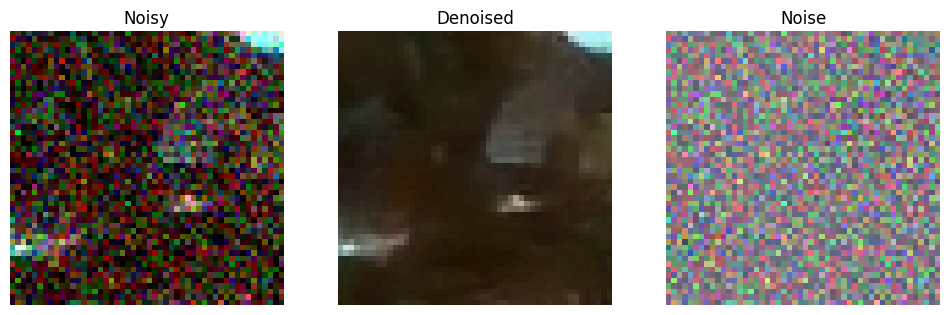

In [21]:
i = 25

pred_cpu = pred.detach().cpu()

noisy = X_test[i].permute(1,2,0).numpy()
residual = pred_cpu[i].permute(1,2,0).numpy()

denoised = noisy - residual

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(noisy)
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(denoised)
plt.title("Denoised")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(noisy-denoised+0.5)
plt.title("Noise")
plt.axis("off")

plt.show()

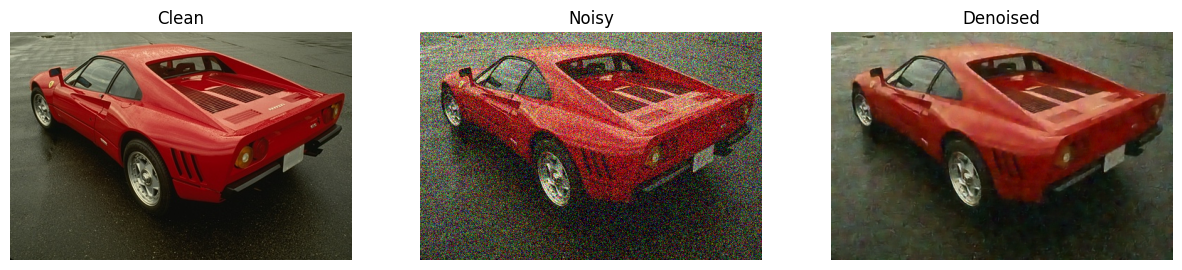

In [58]:
# Load large image
large_img_idx = 11

img = cv2.imread(img_paths_test[large_img_idx])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Add Gaussian noise
noisy, residual = add_gaussian_noise(img)
clean = noisy - residual # no need to clip, already handled by add_gaussian_noise

# Convert to tensor (1,C,H,W)
input_tensor = torch.tensor(noisy).permute(2,0,1).unsqueeze(0).float()

# Predict noise
with torch.no_grad():
    x = input_tensor.to(device)
    predicted_noise = model(x)

predicted_noise_cpu = predicted_noise.detach().cpu()
# Residual learning → subtract noise
denoised_tensor = input_tensor - predicted_noise_cpu

# Convert back to numpy
denoised = denoised_tensor.squeeze(0).permute(1,2,0).cpu().numpy()

# Plot results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(clean)
plt.title("Clean")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy)
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised)
plt.title("Denoised")
plt.axis('off')

plt.show()

In [23]:
torch.save(model, "dncnn_full_model.pth")